##**BiT Dataset Complete Experiments**

##**Common Setup (For all algorithms)**

In [ ]:
# --- FINAL PREPROCESSING
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load dataset ---
from google.colab import files
uploaded = files.upload()  # Upload bit.csv
df = pd.read_csv('bit.csv')

# --- Clean column names ---
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(" Columns in dataset:", list(df.columns))

# --- Define target ---
target_col = 'diabetic'

# --- Clean missing values and strings ---
df.replace(['?', 'NA', 'N/A', 'na', 'null', 'None', ''], np.nan, inplace=True)
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# --- Encode binary Yes/No variables ---
binary_cols = [col for col in df.columns if df[col].dropna().isin(['Yes', 'No']).all()]
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# --- Encode Gender ---
if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# --- Handle text-based Age column ---
if 'age' in df.columns:
    df['age'] = df['age'].replace({
        'less than 40': 1,
        '40-49': 2,
        '50-59': 3,
        '60 or older': 4,
        '<40': 1,
        '40s': 2,
        '50s': 3,
        '60+': 4
    })

# --- Encode any remaining object (categorical) columns automatically ---
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# --- Fill missing values ---
for col in df.columns:
    if df[col].dtype in [np.float64, np.int64]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# --- Split features/target ---
X = df.drop(columns=[target_col])
y = df[target_col]

# --- Train/test split ---
# --- Train/test split (non-stratified if one class is too small) ---
if df[target_col].value_counts().min() < 2:
    print("One class too small, using non-stratified split.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )


# --- Scale numeric features ---
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(" Preprocessing complete | Train shape:", X_train.shape, "Test shape:", X_test.shape)

# --- Evaluation function ---
def evaluate_model(name, y_train, y_pred_train, y_test, y_pred_test):
    print(f"\n{name} Performance")
    print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
    print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_pred_test))
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()




Saving bit.csv to bit (9).csv
 Columns in dataset: ['age', 'gender', 'family_diabetes', 'highbp', 'physicallyactive', 'bmi', 'smoking', 'alcohol', 'sleep', 'soundsleep', 'regularmedicine', 'junkfood', 'stress', 'bplevel', 'pregancies', 'pdiabetes', 'uriationfreq', 'diabetic']
One class too small, using non-stratified split.
 Preprocessing complete | Train shape: (761, 17) Test shape: (191, 17)


/tmp/ipython-input-1618791505.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
/tmp/ipython-input-1618791505.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['age'] = df['age'].replace({


#**1. Decision Tree**


Decision Tree Performance
Train Accuracy: 0.9789750328515112
Test Accuracy: 0.9109947643979057

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.93      0.93      0.93       124
           2       0.87      0.88      0.87        67

    accuracy                           0.91       191
   macro avg       0.90      0.90      0.90       191
weighted avg       0.91      0.91      0.91       191



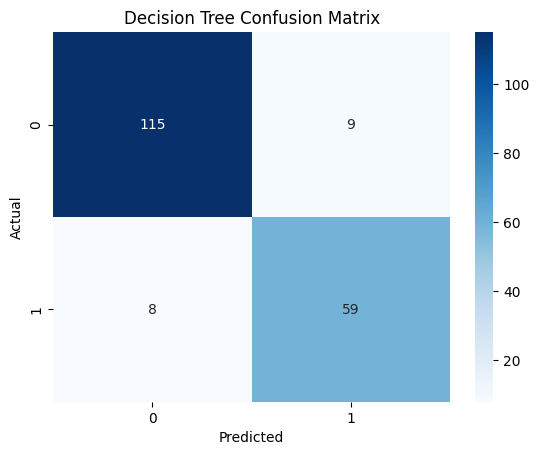

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_train = dt.predict(X_train)
y_pred_test = dt.predict(X_test)

evaluate_model("Decision Tree", y_train, y_pred_train, y_test, y_pred_test)


#**2. K-Nearest Neighbor (KNN)**


KNN Performance 
Train Accuracy: 0.9605781865965834
Test Accuracy: 0.8795811518324608

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.87      0.95      0.91       124
           2       0.89      0.75      0.81        67

    accuracy                           0.88       191
   macro avg       0.88      0.85      0.86       191
weighted avg       0.88      0.88      0.88       191



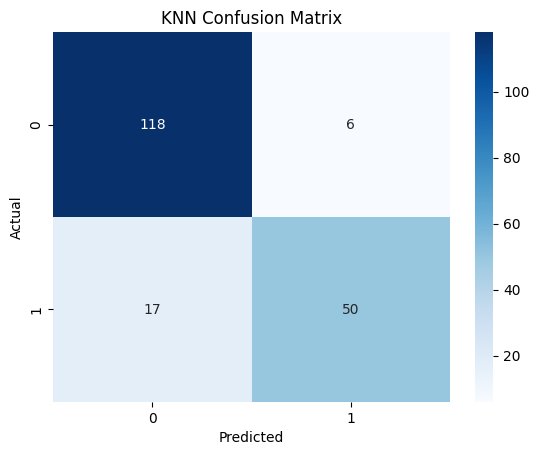

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

def evaluate_model(name, y_train, y_pred_train, y_test, y_pred_test):
    print(f"\n{name} Performance ")
    print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
    print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_pred_test))
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model("KNN", y_train, y_pred_train, y_test, y_pred_test)


#**3. Random Forest**


Random Forest Performance 
Train Accuracy: 0.9816031537450722
Test Accuracy: 0.9319371727748691

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.94      0.95      0.95       124
           2       0.91      0.90      0.90        67

    accuracy                           0.93       191
   macro avg       0.93      0.92      0.93       191
weighted avg       0.93      0.93      0.93       191



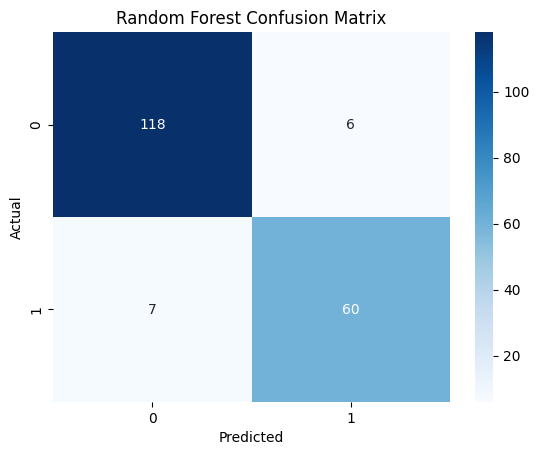

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

evaluate_model("Random Forest", y_train, rf.predict(X_train), y_test, rf.predict(X_test))


#**4.Voting Classifier**


Voting Classifier Performance 
Train Accuracy: 0.9605781865965834
Test Accuracy: 0.9424083769633508

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.94      0.97      0.96       124
           2       0.94      0.90      0.92        67

    accuracy                           0.94       191
   macro avg       0.94      0.93      0.94       191
weighted avg       0.94      0.94      0.94       191



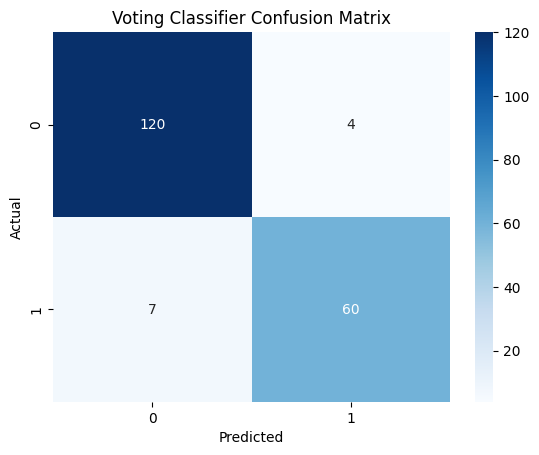

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
svc = SVC(probability=True, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

voting = VotingClassifier(estimators=[
    ('lr', lr), ('svc', svc), ('rf', rf)
], voting='soft')

voting.fit(X_train, y_train)

evaluate_model("Voting Classifier", y_train, voting.predict(X_train), y_test, voting.predict(X_test))


#**5. XGBoost**

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:57:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Performance 
Train Accuracy: 0.9802890932982917
Test Accuracy: 0.9476439790575916

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.95      0.97      0.96       124
           2       0.94      0.91      0.92        67

    accuracy                           0.95       191
   macro avg       0.95      0.94      0.94       191
weighted avg       0.95      0.95      0.95       191



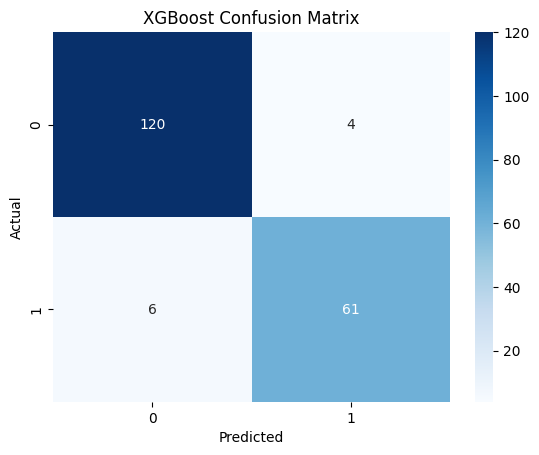

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

evaluate_model("XGBoost", y_train, xgb.predict(X_train), y_test, xgb.predict(X_test))


#**6.KMeans + Decision Tree**


KMeans + Decision Tree Performance 
Train Accuracy: 0.9789750328515112
Test Accuracy: 0.9109947643979057

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.93      0.93      0.93       124
           2       0.87      0.88      0.87        67

    accuracy                           0.91       191
   macro avg       0.90      0.90      0.90       191
weighted avg       0.91      0.91      0.91       191



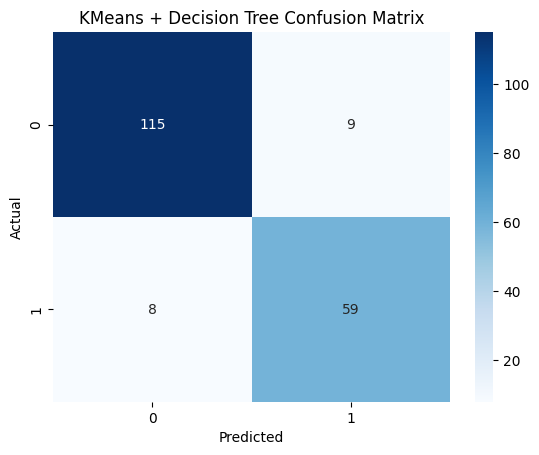

In [ ]:
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier

# Add cluster labels as new feature
kmeans = KMeans(n_clusters=2, random_state=42)
X_train_km = X_train.copy()
X_test_km = X_test.copy()
X_train_km['Cluster'] = kmeans.fit_predict(X_train)
X_test_km['Cluster'] = kmeans.predict(X_test)

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train_km, y_train)

evaluate_model("KMeans + Decision Tree", y_train, dt.predict(X_train_km), y_test, dt.predict(X_test_km))


#**7. KMeans + PCA**


KMeans + PCA Performance 
Train Accuracy: 0.9789750328515112
Test Accuracy: 0.9109947643979057

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.93      0.93      0.93       124
           2       0.87      0.88      0.87        67

    accuracy                           0.91       191
   macro avg       0.90      0.90      0.90       191
weighted avg       0.91      0.91      0.91       191



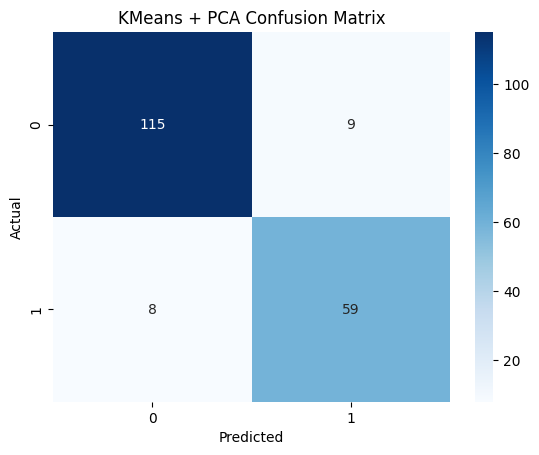

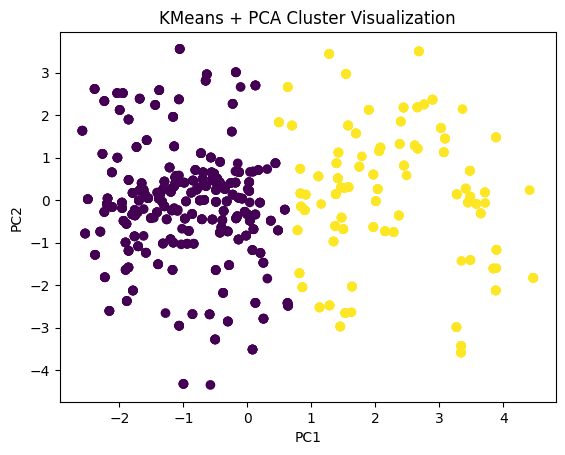

In [ ]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=2, random_state=42)
pca = PCA(n_components=2)
X_scaled = scaler.fit_transform(X)

X_pca = pca.fit_transform(X_scaled)
clusters = kmeans.fit_predict(X_pca)
evaluate_model("KMeans + PCA", y_train, dt.predict(X_train_km), y_test, dt.predict(X_test_km))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title('KMeans + PCA Cluster Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


#**8. Support Vector Machine (SVM)**


SVM Performance 
Train Accuracy: 0.9277266754270697
Test Accuracy: 0.9109947643979057

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.95      0.91      0.93       124
           2       0.86      0.91      0.88        67

    accuracy                           0.91       191
   macro avg       0.60      0.61      0.60       191
weighted avg       0.92      0.91      0.91       191



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


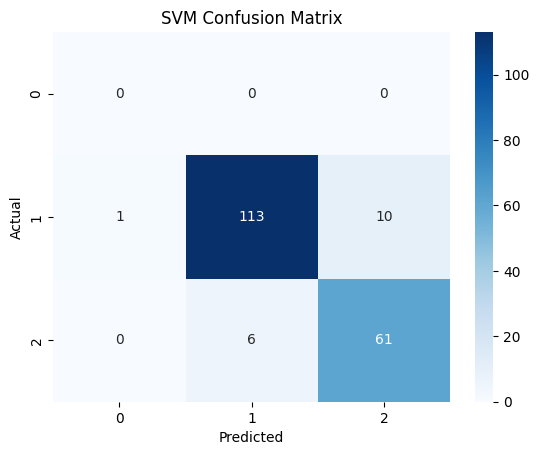

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)

evaluate_model("SVM", y_train, svm.predict(X_train), y_test, svm.predict(X_test))


#**9.KMeans + SVM**


KMeans + SVM Performance 
Train Accuracy: 0.9277266754270697
Test Accuracy: 0.9109947643979057

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.95      0.91      0.93       124
           2       0.86      0.91      0.88        67

    accuracy                           0.91       191
   macro avg       0.60      0.61      0.60       191
weighted avg       0.92      0.91      0.91       191



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


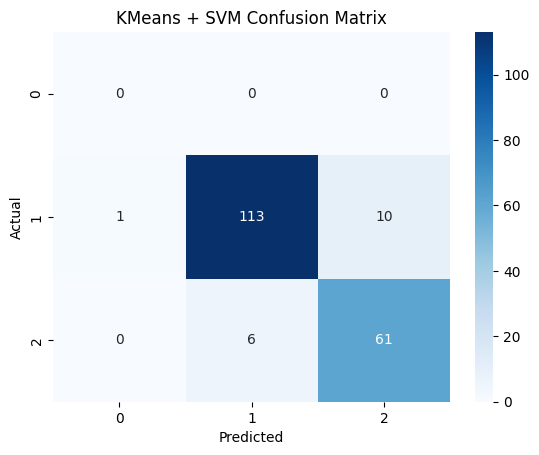

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
X_train_km = X_train.copy()
X_test_km = X_test.copy()
X_train_km['Cluster'] = kmeans.fit_predict(X_train)
X_test_km['Cluster'] = kmeans.predict(X_test)

svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm.fit(X_train_km, y_train)

evaluate_model("KMeans + SVM", y_train, svm.predict(X_train_km), y_test, svm.predict(X_test_km))


#**10.Feed Forward Neural Network (MLP)**


Feed Forward Neural Network Performance 
Train Accuracy: 0.9776609724047306
Test Accuracy: 0.93717277486911

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.94      0.97      0.95       124
           2       0.94      0.88      0.91        67

    accuracy                           0.94       191
   macro avg       0.94      0.92      0.93       191
weighted avg       0.94      0.94      0.94       191



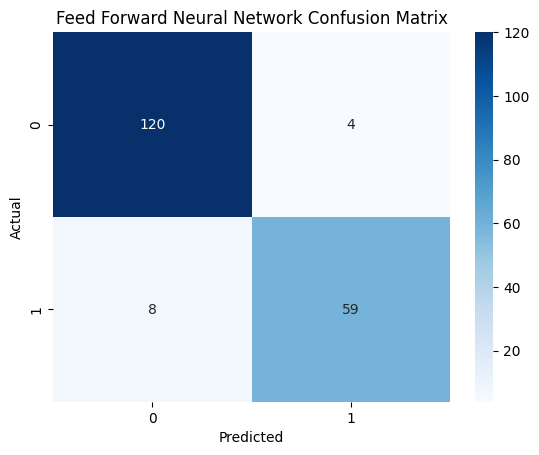

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                    max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

evaluate_model("Feed Forward Neural Network", y_train, mlp.predict(X_train), y_test, mlp.predict(X_test))
